In [7]:
import pandas as pd
import numpy as np

### Import Data

In [21]:
df = pd.read_csv('dataset/Multinomial Naive Bayes/SMSSpamCollection', sep='\t', names=['label', 'messages'])
df.head()

,label,messages
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Evaluation Data

In [22]:
df.describe()

,label,messages
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [18]:
df.isna().sum()

label       0
messages    0
dtype: int64

### Visualize Data

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from wordcloud import WordCloud

In [23]:
label_counts = df['label'].value_counts()
label_percents = df['label'].value_counts(normalize=True) * 100

In [25]:
plt.figure(figsize=(10, 10))
sns.set_theme(style="whitegrid")

<Figure size 1000x1000 with 0 Axes>

/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_87603/1881754623.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, order=label_counts.index, palette='viridis')


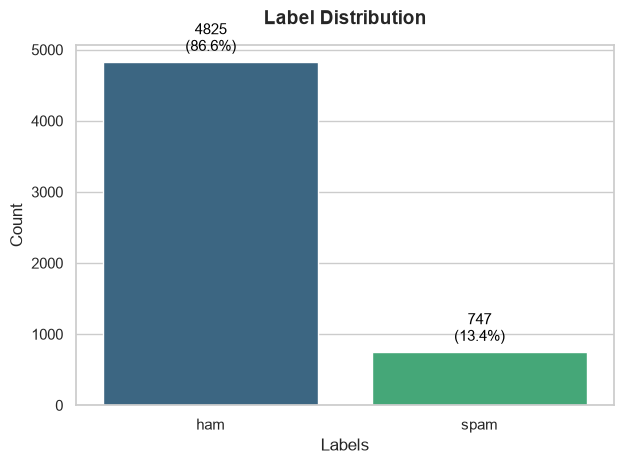

In [29]:
ax = sns.countplot(x='label', data=df, order=label_counts.index, palette='viridis')
for p in ax.patches:
    height = p.get_height()
    percentage = (height / len(df)) * 100
    ax.annotate(f'{int(height)}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', 
                fontsize=11, color='black',
                xytext=(0, 5),
                textcoords='offset points')
plt.title('Label Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Labels', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

In [30]:
df['msg length'] = df['messages'].astype(str).apply(len)

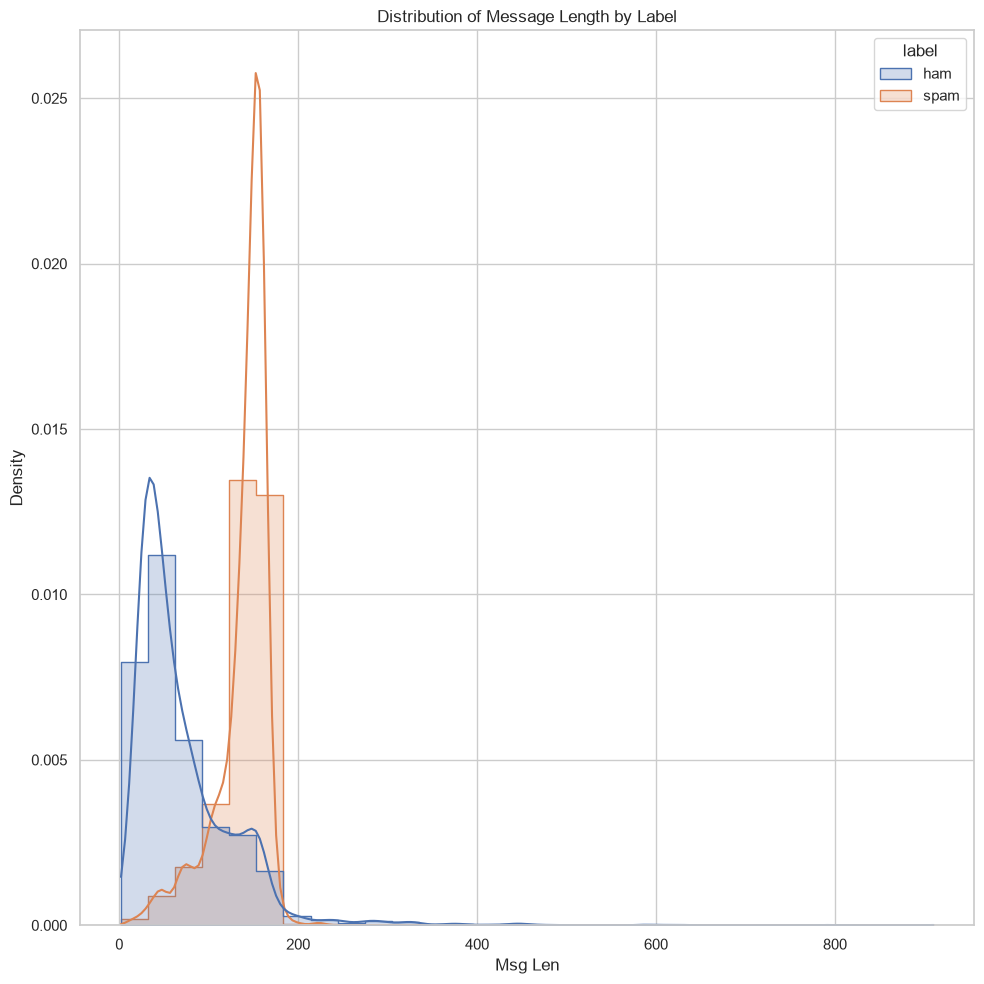

In [32]:
plt.figure(figsize=(10,10))
sns.histplot(
    data=df, 
    x='msg length', 
    hue='label', 
    kde=True, 
    bins=30,
    element="step",
    stat="density",
    common_norm=False)

plt.title('Distribution of Message Length by Label')
plt.xlabel('Msg Len')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

In [ ]:
labels = df["label"].unique()

for label in labels:
    text = " ".join(
        df[df["label"] == label]["message"].astype(str)
    )

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud - {label}")
    plt.show()

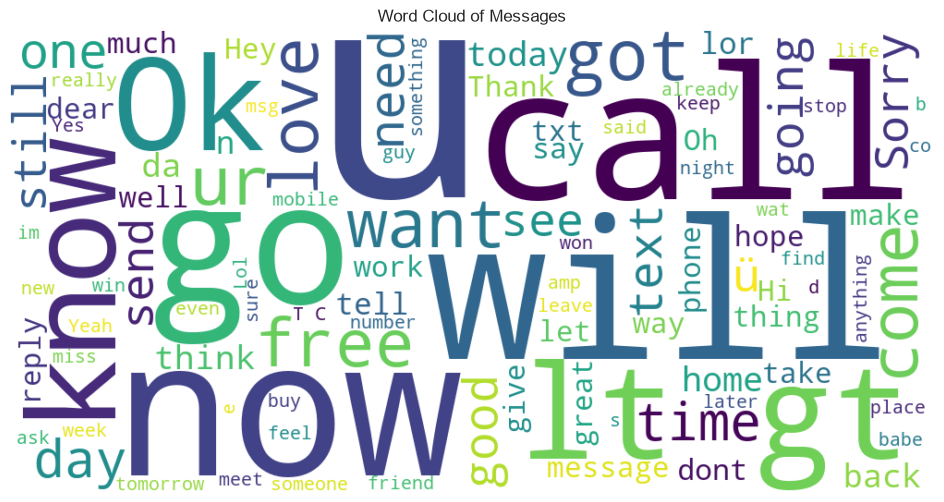

In [35]:
text = " ".join(df["messages"].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Messages")
plt.show()

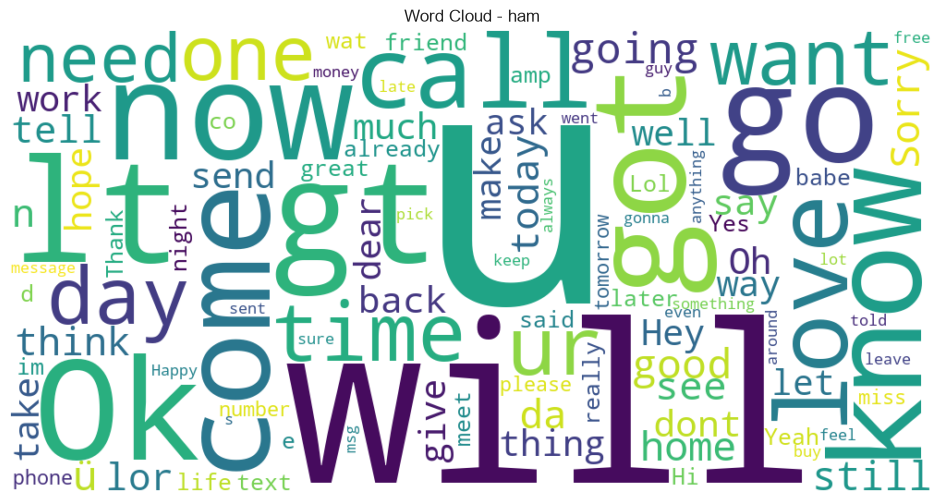

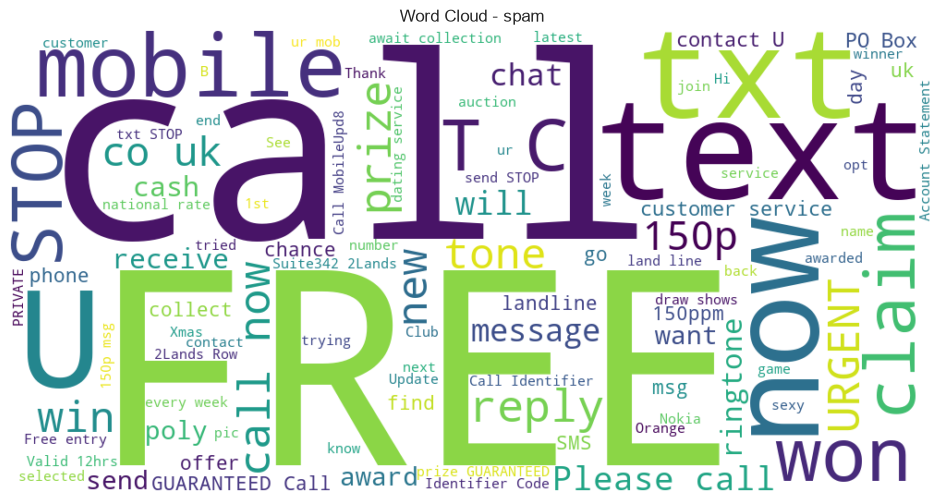

In [40]:
labels = df["label"].unique()

for label in labels:
    text = " ".join(
        df[df["label"] == label]["messages"].astype(str)
    )

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud - {label}")
    plt.show()

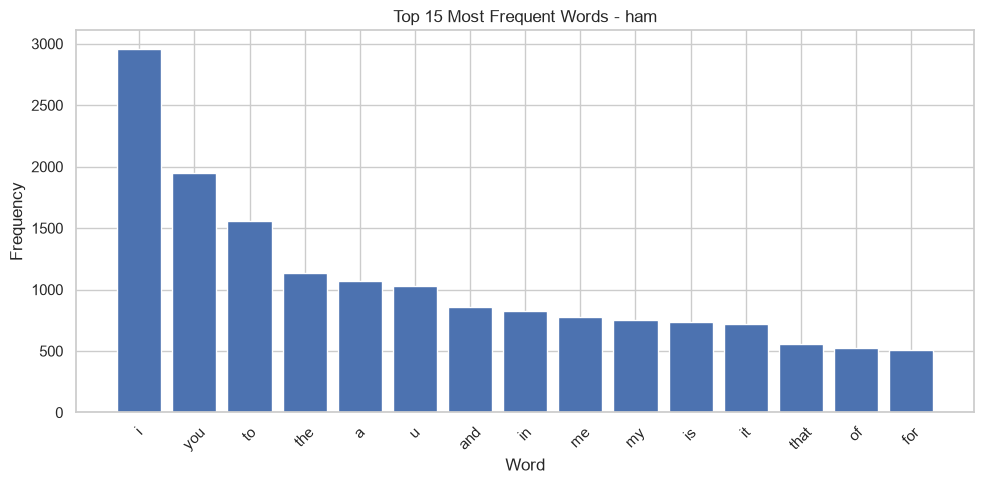

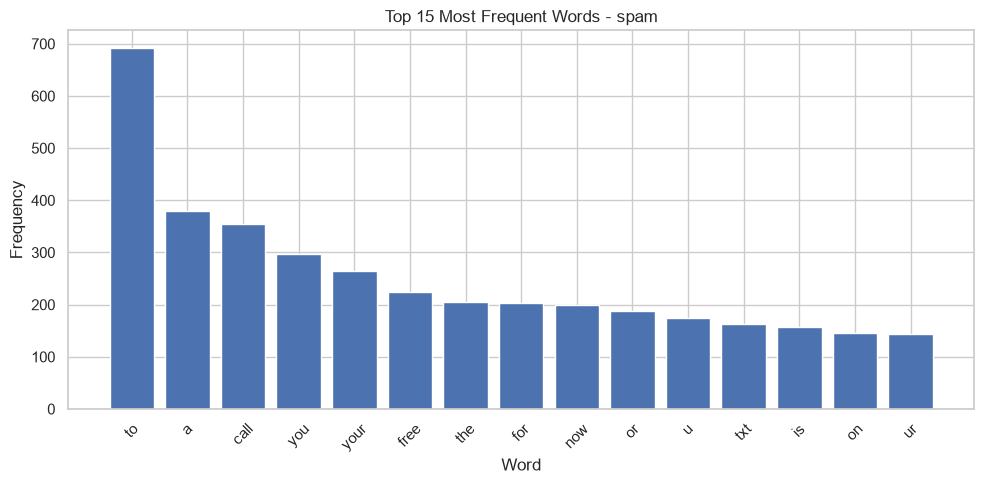

In [42]:
for label in df["label"].unique():

    text = " ".join(
        df[df["label"] == label]["messages"].astype(str)
    ).lower()

    words = re.findall(r"\b[a-zA-Z]+\b", text)

    word_counts = Counter(words)
    top_words = word_counts.most_common(15)

    words = [word for word, count in top_words]
    counts = [count for word, count in top_words]

    plt.figure(figsize=(10, 5))
    plt.bar(words, counts)

    plt.title(f"Top 15 Most Frequent Words - {label}")
    plt.xlabel("Word")
    plt.ylabel("Frequency")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Processing Data

In [ ]:
import math

In [ ]:
df = df.drop(['msg length'], axis=1)
X = df['messages']
y = df['label']

In [62]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    words = text.split()
    return words


In [63]:
def build_vocab(messages):
    vocab = set()
    for msg in messages:
        words = preprocess_text(msg)
        for word in words:
            vocab.add(word)
    return sorted(vocab)

In [64]:
vocab = build_vocab(df['messages'])
print(f"Vocal len: {len(vocab)}")

Vocal len: 8745


In [56]:
# Compute TF - IDF
def calculate_tf(words):

    word_count = {}

    for word in words:
        word_count[word] = word_count.get(word, 0) + 1

    total_words = len(words)

    tf = {}

    for word, count in word_count.items():
        tf[word] = count / total_words

    return tf

In [59]:
def calculate_idf(messages, vocab):

    N = len(messages)

    document_frequency = {
        word: 0
        for word in vocab
    }

    for message in messages:

        words = set(preprocess_text(message))

        for word in words:

            if word in document_frequency:
                document_frequency[word] += 1

    idf = {}

    for word in vocab:

        df_word = document_frequency[word]

        idf[word] = math.log(N / df_word)

    return idf


In [69]:
idf = calculate_idf(df['messages'], vocab)

In [70]:
def tfidf_vectorize(messages, vocabulary, idf):

    vectors = []

    for message in messages:

        words = preprocess_text(message)

        tf = calculate_tf(words)

        vector = []

        for word in vocabulary:

            tf_value = tf.get(word, 0)

            tfidf_value = tf_value * idf[word]

            vector.append(tfidf_value)

        vectors.append(vector)

    return vectors

In [ ]:
X_tfidf = tfidf_vectorize(df['messages'], vocab, idf)

In [74]:
X_tfidf = np.array(X_tfidf)
print(f"The shape of X_tfidf = {X_tfidf.shape}")

The shape of X_tfidf = (5572, 8745)


### Slip Data

In [156]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Train Data

In [109]:
def calculate_word_frequency(X_train, y_train, vocab):

    word_prior = {}

    for label in np.unique(y_train):

        df_label = X_train[y_train == label]
        total_words = df_label.sum()
        word_prior[label] = {}

        for i, word in enumerate(vocab):
            word_frequency = df_label[:, i].sum()
            word_prior[label][word] = float(word_frequency) / total_words

    return word_prior


In [162]:
# Apply Laplace
def calculate_word_frequency_laplace(X_train, y_train, vocab):

    word_prior = {}

    for label in np.unique(y_train):

        df_label = X_train[y_train == label]
        total_words = df_label.sum()
        word_prior[label] = {}

        for i, word in enumerate(vocab):
            word_frequency = df_label[:, i].sum()
            word_prior[label][word] = float(word_frequency + 1) / (total_words + X_train.shape[1])

    return word_prior

In [147]:
def predict_one(vector, class_prior, word_probabilities):

    scores = {}

    for label in class_prior:

        score = np.log(class_prior[label])
        probabilities = word_probabilities[label]
        for idx, count in enumerate(vector):

            if count > 0:
                word = vocab[idx]
                score += count * np.log(probabilities[word])

        scores[label] = score
        
    return max(scores, key=scores.get)

In [133]:
def predict(X_test, class_prior, word_probabilities):
    
    predictions = []

    for vector in X_test:

        predictions.append(
            predict_one(vector, class_prior, word_probabilities)
        )

    return np.array(predictions)


In [130]:
class_prior = {}
N = len(y_train)
class_counter = Counter(y_train)

for label, count in class_counter.items():
    class_prior[label] = count / N

print(f"Class Prior: {class_prior}")

Class Prior: {'ham': 0.8658290329818263, 'spam': 0.13417096701817366}


In [163]:
word_prior = calculate_word_frequency_laplace(X_train, y_train, vocab)

### Predict Data

In [164]:
y_pred = predict(X_train, class_prior, word_prior)

In [167]:
y_test_pred = predict(X_test, class_prior, word_prior)

### Evaluation Prediction

In [165]:
from sklearn.metrics import classification_report

print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      3859
        spam       1.00      0.86      0.92       598

    accuracy                           0.98      4457
   macro avg       0.99      0.93      0.96      4457
weighted avg       0.98      0.98      0.98      4457



In [166]:
print("y_test:", np.unique(y_train, return_counts=True))
print("y_pred:", np.unique(y_pred, return_counts=True))

y_test: (array(['ham', 'spam'], dtype=object), array([3859,  598]))
y_pred: (array(['ham', 'spam'], dtype='<U4'), array([3944,  513]))


In [168]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

         ham       0.97      0.99      0.98       966
        spam       0.93      0.79      0.85       149

    accuracy                           0.96      1115
   macro avg       0.95      0.89      0.91      1115
weighted avg       0.96      0.96      0.96      1115



In [169]:
print("y_test:", np.unique(y_train, return_counts=True))
print("y_pred:", np.unique(y_pred, return_counts=True))

y_test: (array(['ham', 'spam'], dtype=object), array([3859,  598]))
y_pred: (array(['ham', 'spam'], dtype='<U4'), array([3944,  513]))
